# Unit10 Example 01 - 平板之非穩態熱傳導 (Transient Heat Conduction in a Slab)

本 Notebook 示範如何使用 `py-pde` 套件與 **Method of Lines (MoL)** 求解一維拋物線型 PDE（熱傳導方程式），並與 Fourier 級數解析解進行驗證比較。

## 學習目標
- 使用 `py-pde` 的 `DiffusionPDE` 直接求解非穩態熱傳方程式
- 使用 Method of Lines (MoL) 搭配 `scipy.integrate.solve_ivp()` 求解同一問題
- 推導並計算 Fourier 級數解析解，驗證數值方法
- 探討網格取點密度對數值精度的影響
- 繪製溫度場時空演變曲面圖與特定時刻之軸向分布圖

> **參考來源：** 改編自教材第五章範例 5-1 及範例 5-3-4（呂，1985）

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_01\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# py-pde 套件
import pde

# scipy
from scipy.integrate import solve_ivp

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")
print(f"  pde        版本: {pde.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8
  pde        版本: 0.51.0


---
### 2. 問題參數設定

**問題：** 一維平板非穩態熱傳導（改編自教材第五章範例 5-3-4）

- **統御方程式：** $\partial T / \partial t = \alpha \, \partial^2 T / \partial x^2$
- **初始條件：** $T(x, 0) = T_0 = 0\,°\text{C}$
- **邊界條件：** $T(0,t) = T_L = 100\,°\text{C}$，$T(L,t) = T_R = 50\,°\text{C}$
- **熱擴散率：** $\alpha = k / (\rho C_p) = 10 / (10 \times 500) = 0.002 \text{ m}^2/\text{s}$

In [14]:
# ========================================
# 物理與幾何參數
# ========================================
L     = 10.0     # 平板長度 [m]
k     = 10.0     # 熱傳導係數 [W/(m·°C)]
rho   = 10.0     # 密度 [kg/m³]
Cp    = 500.0    # 熱容量 [J/(kg·°C)]
alpha = k / (rho * Cp)    # 熱擴散率 [m²/s]

# ========================================
# 初始條件與邊界條件
# ========================================
T_0   = 0.0      # 初始溫度 [°C]
T_L   = 100.0    # 左端溫度 [°C] (x = 0)
T_R   = 50.0     # 右端溫度 [°C] (x = L)

# ========================================
# 模擬時間
# ========================================
t_f   = 600.0    # 模擬總時長 [s]

print("=" * 45)
print("  問題參數摘要")
print("=" * 45)
print(f"  平板長度   L     = {L} m")
print(f"  熱傳導係數 k     = {k} W/(m·°C)")
print(f"  密度       rho   = {rho} kg/m³")
print(f"  熱容量     Cp    = {Cp} J/(kg·°C)")
print(f"  熱擴散率   alpha = {alpha} m²/s")
print(f"  初始溫度   T_0   = {T_0} °C")
print(f"  左端溫度   T_L   = {T_L} °C")
print(f"  右端溫度   T_R   = {T_R} °C")
print(f"  模擬時間   t_f   = {t_f} s")
# ========================================
# 特性時間尺度
# ========================================
tau = L**2 / (np.pi**2 * alpha)    # 熱擴散特性時間 [s]
print(f"  熱擴散特性時間 τ  = {tau:.1f} s  (L²/π²α)")
print(f"  t_f / τ        = {t_f/tau:.4f}  (t=600s 約 {t_f/tau*100:.1f}% 趨近穩態)")
print("=" * 45)

  問題參數摘要
  平板長度   L     = 10.0 m
  熱傳導係數 k     = 10.0 W/(m·°C)
  密度       rho   = 10.0 kg/m³
  熱容量     Cp    = 500.0 J/(kg·°C)
  熱擴散率   alpha = 0.002 m²/s
  初始溫度   T_0   = 0.0 °C
  左端溫度   T_L   = 100.0 °C
  右端溫度   T_R   = 50.0 °C
  模擬時間   t_f   = 600.0 s
  熱擴散特性時間 τ  = 5066.1 s  (L²/π²α)
  t_f / τ        = 0.1184  (t=600s 約 11.8% 趨近穩態)


---
### 3. Fourier 級數解析解 (Analytical Solution)

解析解的形式為：

$$
T(x, t) = T_\text{ss}(x) + \sum_{n=1}^{N_\text{terms}} B_n \sin\!\left(\frac{n\pi x}{L}\right) \exp\!\left(-\alpha \left(\frac{n\pi}{L}\right)^2 t\right)
$$

其中穩態解為：

$$
T_\text{ss}(x) = T_L + (T_R - T_L)\frac{x}{L} = 100 - 5x
$$

Fourier 係數（一般形式，適用任意 $T_0$）：

$$
B_n = \frac{2}{n\pi}\left[(T_0 - T_L)(1 - (-1)^n) + (T_R - T_L)(-1)^n\right]
$$

本題 $T_0 = 0$ 時代入得：

$$
B_n = \frac{2}{n\pi}\left[-T_L(1 - (-1)^n) + (T_R - T_L)(-1)^n\right]
$$

In [18]:
def analytical_solution(x, t, L, alpha, T_L, T_R, T_0, N_terms=100):
    """
    計算一維平板非穩態熱傳導的 Fourier 級數解析解。

    Parameters
    ----------
    x      : array-like, 空間座標 [m]
    t      : float, 時間 [s]
    L      : float, 平板長度 [m]
    alpha  : float, 熱擴散率 [m²/s]
    T_L    : float, 左端溫度 [°C]
    T_R    : float, 右端溫度 [°C]
    T_0    : float, 初始均勻溫度 [°C]
    N_terms: int, Fourier 級數截斷項數（預設 100 項）

    Returns
    -------
    T : ndarray, 對應 x 位置的溫度值
    """
    x = np.asarray(x)
    # 穩態解（線性內插）
    T_ss = T_L + (T_R - T_L) * x / L
    # 初始溫度偏差 u0(x) = T_0 - T_ss(x)
    # u0(x) = T_0 - T_L - (T_R - T_L)*x/L
    # Fourier sine series of u0(x) on [0, L]
    # B_n = (2/L) ∫₀ᴸ u0(x) sin(nπx/L) dx
    # 解析積分（一般情況，含任意 T_0）：
    #   u0(x) = (T_0-T_L) - (T_R-T_L)*x/L
    #   常數部分 (T_0-T_L) : ∫₀ᴸ sin(nπx/L) dx = L/(nπ)*(1-(-1)^n)
    #   線性部分 -(T_R-T_L)/L : ∫₀ᴸ x*sin(nπx/L) dx = L²*(-1)^(n+1)/(nπ)
    # ∴ B_n = 2/(nπ) * [(T_0-T_L)*(1-(-1)^n) + (T_R-T_L)*(-1)^n]

    T_transient = np.zeros_like(x, dtype=float)
    for n in range(1, N_terms + 1):
        lam_n = n * np.pi / L
        # Fourier 係數 B_n
        Bn = (2.0 / (n * np.pi)) * (
            (T_0 - T_L) * (1.0 - (-1.0)**n)
            + (T_R - T_L) * (-1.0)**n
        )
        T_transient += Bn * np.sin(lam_n * x) * np.exp(-alpha * lam_n**2 * t)
    return T_ss + T_transient


# 建立空間坐標（含端點，用於顯示全域解）
x_exact = np.linspace(0, L, 500)

# 驗證 1：以較多項數確認 t→0 時中點溫度趨近初始溫度
T_t0 = analytical_solution(np.array([L/2]), 1e-6, L, alpha, T_L, T_R, T_0, N_terms=1000)[0]
print(f"解析解驗證 (t→0, N=1000): T(L/2, 0) = {T_t0:.3f} °C")
print(f"  期望值 (初始溫度 T_0): {T_0} °C  [Gibbs現象: 截斷項數影響 t≈0 收斂]")

# 驗證 2：穩態解（t→∞）
T_ss_check = analytical_solution(np.array([L/2]), 1e6, L, alpha, T_L, T_R, T_0)[0]
T_ss_exact = T_L + (T_R - T_L) * (L/2) / L
print(f"解析解驗證 (t→∞): T(L/2, ∞) = {T_ss_check:.3f} °C")
print(f"  期望值 (穩態線性內插):  {T_ss_exact:.3f} °C")

解析解驗證 (t→0, N=1000): T(L/2, 0) = 0.048 °C
  期望值 (初始溫度 T_0): 0.0 °C  [Gibbs現象: 截斷項數影響 t≈0 收斂]
解析解驗證 (t→∞): T(L/2, ∞) = 75.000 °C
  期望值 (穩態線性內插):  75.000 °C


---
### 4. 方法一：`py-pde` 直接求解 (DiffusionPDE)

`py-pde` 提供高階抽象介面，直接表達並求解擴散方程式：

$$
\frac{\partial T}{\partial t} = \alpha \nabla^2 T
$$

**核心步驟：**
1. 建立 `CartesianGrid` 一維網格
2. 設定初始 `ScalarField`
3. 定義 Dirichlet 邊界條件
4. 建立 `DiffusionPDE` 方程式物件
5. 呼叫 `solve()` 求解並追蹤中間結果

In [7]:
# ========================================
# 方法一：py-pde 求解
# ========================================
N_grid = 50    # 空間網格節點數（內部節點）

# 1. 建立一維笛卡兒網格 [0, L]，N_grid 個節點
grid = pde.CartesianGrid([(0, L)], N_grid, periodic=False)

# 2. 設定初始場（均勻初始溫度 T_0）
state = pde.ScalarField(grid, data=T_0)

# 3. 設定兩端 Dirichlet 邊界條件
#    py-pde 邊界條件格式: [左端條件, 右端條件]
bc = [{"value": T_L}, {"value": T_R}]

# 4. 建立擴散 PDE：∂T/∂t = alpha * ∇²T
eq = pde.DiffusionPDE(diffusivity=alpha, bc=bc)

# 5. 設定結果儲存追蹤器（每 dt_store 秒儲存一次）
dt_store = 5.0   # 儲存時間間隔 [s]
storage_pypde = pde.MemoryStorage()

# 6. 執行求解
result_pypde = eq.solve(
    state,
    t_range=t_f,
    dt=0.5,      # 時間步長 [s]（自動穩定性控制）
    tracker=[storage_pypde.tracker(dt_store)]
)

# 擷取結果：空間座標、時間序列、溫度矩陣
x_pypde   = grid.axes_coords[0]                                    # 空間座標 [m]
t_pypde   = np.array(storage_pypde.times)                         # 時間序列 [s]
T_pypde   = np.array([field.data for field in storage_pypde])     # 溫度矩陣 [t, x]

print(f"✓ py-pde 求解完成")
print(f"  空間節點數:   {len(x_pypde)}")
print(f"  時間點數:     {len(t_pypde)}")
print(f"  溫度矩陣形狀: {T_pypde.shape}")
print(f"  最終時刻溫度範圍: [{T_pypde[-1].min():.2f}, {T_pypde[-1].max():.2f}] °C")

✓ py-pde 求解完成
  空間節點數:   50
  時間點數:     121
  溫度矩陣形狀: (121, 50)
  最終時刻溫度範圍: [0.18, 94.84] °C


---
### 5. 方法二：Method of Lines (MoL) + `scipy.integrate.solve_ivp()`

**原理：** 將空間方向用中央差分離散化，PDE → 耦合 ODE 系統：

$$
\frac{dT_i}{dt} = \frac{\alpha}{(\Delta x)^2}(T_{i-1} - 2T_i + T_{i+1}), \quad i = 1, \ldots, N
$$

邊界節點 $T_0 = T_L$，$T_{N+1} = T_R$ 為已知常數。

> **求解器：** 使用 `method='Radau'`（隱式 Runge-Kutta），適合空間網格密集時可能出現的 Stiff ODE。

In [8]:
# ========================================
# 方法二：Method of Lines (MoL) + solve_ivp
# ========================================
N_mol = N_grid   # 使用相同的內部節點數以利比較
dx    = L / (N_mol + 1)           # 網格間距 [m]
x_mol = np.linspace(dx, L - dx, N_mol)  # 內部節點座標 [m]

print(f"MoL 設定：N_mol = {N_mol}，dx = {dx:.4f} m")
print(f"Von Neumann 穩定性條件（Explicit）: "
      f"dt ≤ dx²/(2α) = {dx**2 / (2*alpha):.2f} s")
print(f"  → 使用隱式 Radau 求解器，不受此限制")

def heat_mol_ode(t, T_vec):
    """
    MoL ODE 右端函數。

    Parameters
    ----------
    t     : float, 當前時間（solve_ivp 必要參數，本問題不直接使用）
    T_vec : ndarray (N_mol,), 內部節點溫度向量

    Returns
    -------
    dTdt : ndarray (N_mol,), 各節點溫度對時間的導數
    """
    # 構造含邊界的完整溫度向量 T_full = [T_L, T_1, ..., T_N, T_R]
    T_full = np.empty(N_mol + 2)
    T_full[0]    = T_L       # 左邊界 (Dirichlet)
    T_full[1:-1] = T_vec     # 內部節點
    T_full[-1]   = T_R       # 右邊界 (Dirichlet)
    # 中央差分：d²T/dx² ≈ (T_{i-1} - 2*T_i + T_{i+1}) / dx²
    dTdt = alpha / dx**2 * (T_full[:-2] - 2*T_full[1:-1] + T_full[2:])
    return dTdt

# ---- 初始條件 ----
T_init_mol = np.full(N_mol, T_0)

# ---- 設定輸出時間點（與 py-pde 相同的時間序列）----
t_eval_mol = np.arange(0, t_f + dt_store, dt_store)

# ---- 呼叫 solve_ivp ----
sol_mol = solve_ivp(
    heat_mol_ode,
    t_span=(0, t_f),
    y0=T_init_mol,
    method='Radau',      # 適合 Stiff ODE
    t_eval=t_eval_mol,
    rtol=1e-6,
    atol=1e-8,
    dense_output=False
)

# 擷取結果
t_mol   = sol_mol.t            # 時間序列 [s]
T_mol   = sol_mol.y.T          # 溫度矩陣 [t, x]（轉置）

print(f"\n✓ MoL + Radau 求解完成 (status={sol_mol.status})")
print(f"  內部節點數: {len(x_mol)}")
print(f"  時間點數:   {len(t_mol)}")
print(f"  溫度矩陣形狀: {T_mol.shape}")
print(f"  最終時刻溫度範圍: [{T_mol[-1].min():.2f}, {T_mol[-1].max():.2f}] °C")

MoL 設定：N_mol = 50，dx = 0.1961 m
Von Neumann 穩定性條件（Explicit）: dt ≤ dx²/(2α) = 9.61 s
  → 使用隱式 Radau 求解器，不受此限制

✓ MoL + Radau 求解完成 (status=0)
  內部節點數: 50
  時間點數:   121
  溫度矩陣形狀: (121, 50)
  最終時刻溫度範圍: [0.19, 89.92] °C


---
### 6. 結果比較與視覺化

以下繪製三組圖形，分別用於驗證與分析：
- **Figure 1：** 時空溫度演變曲面圖（py-pde 與 MoL 對比）
- **Figure 2：** 特定時刻之溫度軸向分布（含 Fourier 解析解驗證）
- **Figure 3：** 最終時刻解（t=600 s）與 Fourier 解析解之誤差分析（注意：t_f/τ ≈ 0.12，尚未達穩態）

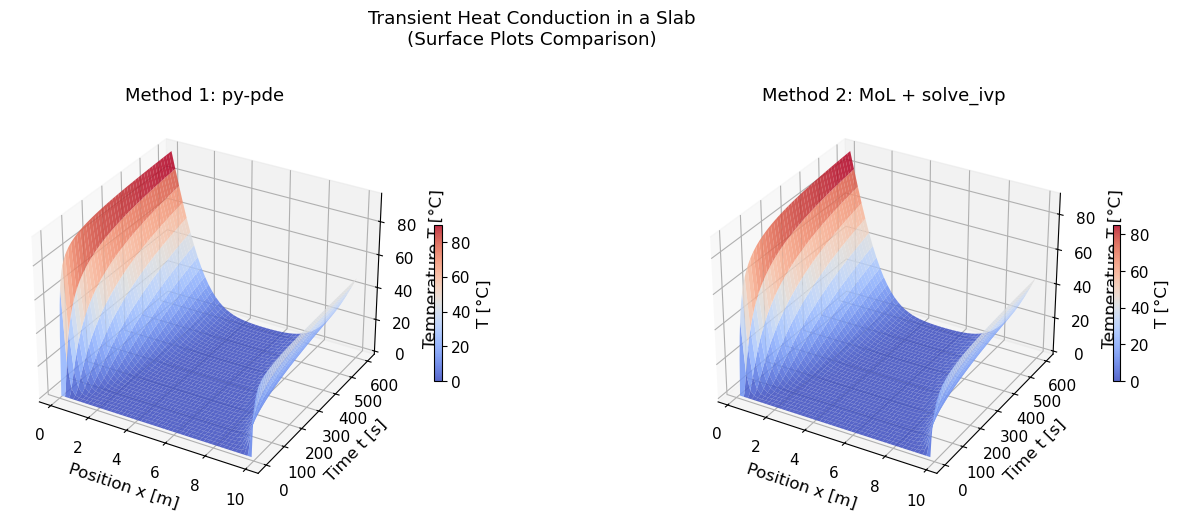

Figure 1 儲存完成


In [9]:
# ========================================
# Figure 1：時空溫度演變曲面圖 (Surface Plot)
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})

for ax, (T_mat, x_c, t_c, label) in zip(
    axes,
    [
        (T_pypde, x_pypde, t_pypde, "Method 1: py-pde"),
        (T_mol,   x_mol,   t_mol,   "Method 2: MoL + solve_ivp"),
    ]
):
    X_mesh, T_mesh_grid = np.meshgrid(x_c, t_c)
    surf = ax.plot_surface(X_mesh, T_mesh_grid, T_mat,
                           cmap='coolwarm', alpha=0.85, linewidth=0)
    ax.set_xlabel("Position x [m]")
    ax.set_ylabel("Time t [s]")
    ax.set_zlabel("Temperature T [°C]")
    ax.set_title(label)
    ax.view_init(elev=30, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.4, label="T [°C]")

plt.suptitle("Transient Heat Conduction in a Slab\n(Surface Plots Comparison)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_surface_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 儲存完成")

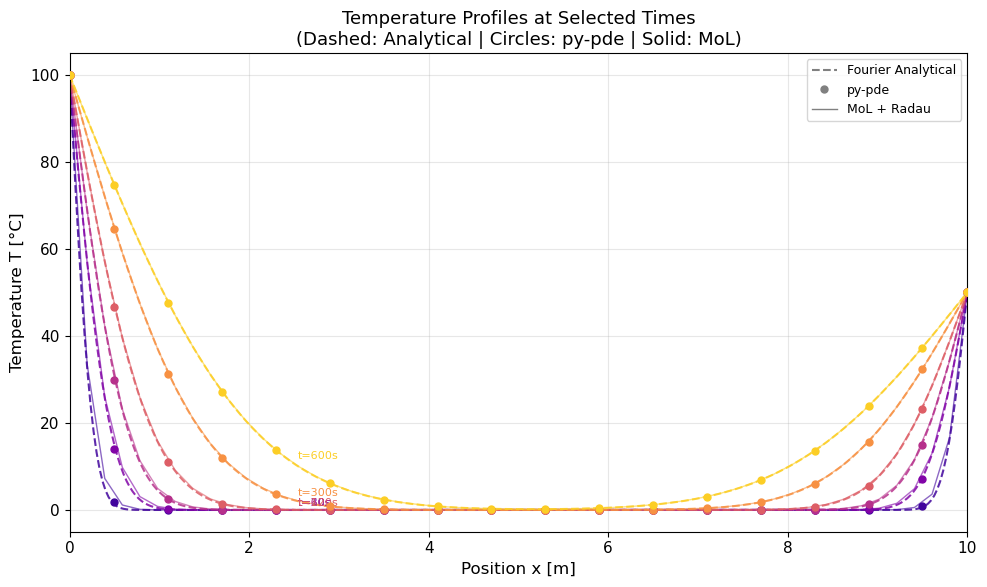

Figure 2 儲存完成


In [10]:
# ========================================
# Figure 2：特定時刻之溫度軸向分布（含解析解驗證）
# ========================================
t_plot_targets = [10, 30, 60, 120, 300, 600]   # 欲繪製的時刻 [s]
x_dense = np.linspace(0, L, 300)               # 高密度空間點（供解析解繪圖）

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_plot_targets)))

for t_target, color in zip(t_plot_targets, colors):
    # ----- 解析解 -----
    T_ana = analytical_solution(x_dense, t_target, L, alpha, T_L, T_R, T_0)
    ax.plot(x_dense, T_ana, '--', color=color, lw=1.5, alpha=0.85,
            label=f"Analytical t={t_target}s")

    # ----- py-pde 解 -----
    idx_pde = np.argmin(np.abs(t_pypde - t_target))
    # 加入邊界點以顯示完整 [0, L] 範圍
    x_pde_full = np.concatenate([[0], x_pypde, [L]])
    T_pde_full = np.concatenate([[T_L], T_pypde[idx_pde], [T_R]])
    ax.scatter(x_pde_full[::3], T_pde_full[::3], s=25, color=color,
               marker='o', zorder=5)

    # ----- MoL 解 -----
    idx_mol = np.argmin(np.abs(t_mol - t_target))
    x_mol_full = np.concatenate([[0], x_mol, [L]])
    T_mol_full = np.concatenate([[T_L], T_mol[idx_mol], [T_R]])
    ax.plot(x_mol_full, T_mol_full, '-', color=color, lw=1.0, alpha=0.6)

# 自訂圖例（避免重複）
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], linestyle='--', color='gray', lw=1.5, label='Fourier Analytical'),
    Line2D([0], [0], linestyle='none', marker='o', color='gray', markersize=5, label='py-pde'),
    Line2D([0], [0], linestyle='-', color='gray', lw=1.0, label='MoL + Radau'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

# 添加時間標籤
for t_target, color in zip(t_plot_targets, colors):
    T_mid = analytical_solution(np.array([L*0.25]), t_target, L, alpha, T_L, T_R, T_0)[0]
    ax.annotate(f"t={t_target}s", xy=(L*0.25, T_mid),
                xytext=(3, 3), textcoords='offset points',
                fontsize=8, color=color)

ax.set_xlabel("Position x [m]")
ax.set_ylabel("Temperature T [°C]")
ax.set_title("Temperature Profiles at Selected Times\n"
             "(Dashed: Analytical | Circles: py-pde | Solid: MoL)")
ax.set_xlim(0, L)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_profile_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 儲存完成")

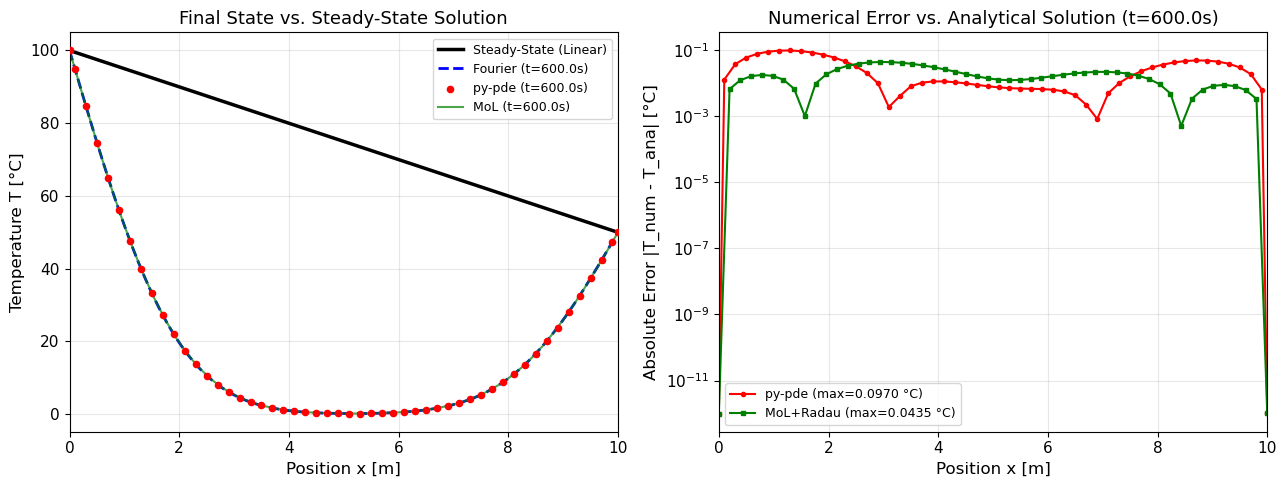

Figure 3 儲存完成

  數值誤差摘要（相較 Fourier 解析解，t = 600s）
  py-pde:       最大絕對誤差 = 0.096993 °C
                平均絕對誤差 = 0.028200 °C
  MoL + Radau:  最大絕對誤差 = 0.043516 °C
                平均絕對誤差 = 0.017288 °C


In [19]:
# ========================================
# Figure 3：最終時刻解比較與誤差分析
# ========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---- 最終時刻溫度比較（t_f/τ≈0.12，尚未達穩態）----
T_ss_exact = T_L + (T_R - T_L) * x_dense / L   # 線性穩態解析解

# 解析解 (Fourier，t=600s，尚未達穩態 t_f/τ≈0.12)
T_ana_final = analytical_solution(x_dense, t_f, L, alpha, T_L, T_R, T_0)

# py-pde 最終時刻（加邊界）
x_pde_full = np.concatenate([[0], x_pypde, [L]])
T_pde_final = np.concatenate([[T_L], T_pypde[-1], [T_R]])

# MoL 最終時刻（加邊界）
x_mol_full = np.concatenate([[0], x_mol, [L]])
T_mol_final = np.concatenate([[T_L], T_mol[-1], [T_R]])

ax1.plot(x_dense, T_ss_exact, 'k-', lw=2.5, label="Steady-State (Linear)")
ax1.plot(x_dense, T_ana_final, 'b--', lw=2, label=f"Fourier (t={t_f}s)")
ax1.scatter(x_pde_full, T_pde_final, s=20, color='red',
            label=f"py-pde (t={t_f}s)", zorder=5)
ax1.plot(x_mol_full, T_mol_final, 'g-', lw=1.5, alpha=0.7,
         label=f"MoL (t={t_f}s)")
ax1.set_xlabel("Position x [m]")
ax1.set_ylabel("Temperature T [°C]")
ax1.set_title("Final State vs. Steady-State Solution")
ax1.legend(fontsize=9)
ax1.set_xlim(0, L)

# ---- 數值誤差分析（絕對誤差 vs 解析解）----
# 直接在數值解相同 x 節點計算解析解，不需內插
T_ana_at_x = analytical_solution(x_pde_full, t_f, L, alpha, T_L, T_R, T_0)
err_pde = np.abs(T_pde_final - T_ana_at_x)
err_pde_rel = err_pde / (np.abs(T_ana_at_x) + 1e-10) * 100

T_ana_at_xmol = analytical_solution(x_mol_full, t_f, L, alpha, T_L, T_R, T_0)
err_mol = np.abs(T_mol_final - T_ana_at_xmol)
err_mol_rel = err_mol / (np.abs(T_ana_at_xmol) + 1e-10) * 100

ax2.semilogy(x_pde_full, err_pde + 1e-12, 'r-o', ms=3, lw=1.5,
             label=f"py-pde (max={err_pde.max():.4f} °C)")
ax2.semilogy(x_mol_full, err_mol + 1e-12, 'g-s', ms=3, lw=1.5,
             label=f"MoL+Radau (max={err_mol.max():.4f} °C)")
ax2.set_xlabel("Position x [m]")
ax2.set_ylabel("Absolute Error |T_num - T_ana| [°C]")
ax2.set_title(f"Numerical Error vs. Analytical Solution (t={t_f}s)")
ax2.legend(fontsize=9)
ax2.set_xlim(0, L)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_steadystate_error.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 儲存完成")

# ---- 誤差摘要 ----
print("\n" + "="*55)
print("  數值誤差摘要（相較 Fourier 解析解，t = 600s）")
print("="*55)
print(f"  py-pde:       最大絕對誤差 = {err_pde.max():.6f} °C")
print(f"                平均絕對誤差 = {err_pde.mean():.6f} °C")
print(f"  MoL + Radau:  最大絕對誤差 = {err_mol.max():.6f} °C")
print(f"                平均絕對誤差 = {err_mol.mean():.6f} °C")
print("="*55)

---
### 7. 網格密度敏感性分析

探討不同空間網格取點數 $N$ 對數值解精度的影響。

  網格密度分析 (t = 60.0 s)
      N    dx [m]      MAE [°C]   MaxErr [°C]
-------------------------------------------------------
      5    1.6667      0.891949      4.073019
     10    0.9091      0.898589      6.292967
     20    0.4762      0.269099      2.244812
     50    0.1961      0.055079      0.425465
    100    0.0990      0.014033      0.109435


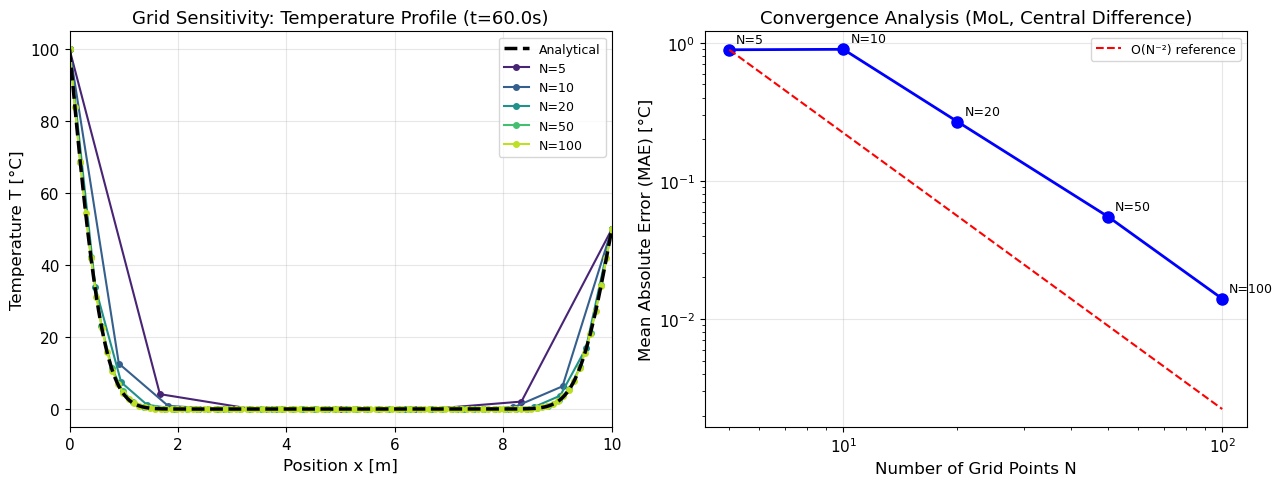

Figure 4 儲存完成


In [15]:
# ========================================
# 網格密度敏感性分析（MoL 方法）
# ========================================
N_list    = [5, 10, 20, 50, 100]
t_check   = 60.0    # 檢驗時刻 [s]
# 注意：t=60s 時熱擴散長度 ≈ √(α·t) ≈ 0.35 m，遠小於 L=10m
# 因此邊界層非常薄，極粗網格（N=5, 10）可能出現非單調收斂，
# 這是粗網格無法解析高梯度邊界層的正常現象，N≥20 後回歸 O(dx²) 收斂。

results_grid = {}
for N_test in N_list:
    dx_test   = L / (N_test + 1)
    x_test    = np.linspace(dx_test, L - dx_test, N_test)

    def heat_test(t, T_vec):
        T_full = np.empty(N_test + 2)
        T_full[0]    = T_L
        T_full[1:-1] = T_vec
        T_full[-1]   = T_R
        return alpha / dx_test**2 * (T_full[:-2] - 2*T_full[1:-1] + T_full[2:])

    sol_test = solve_ivp(
        heat_test,
        t_span=(0, t_check),
        y0=np.full(N_test, T_0),
        method='Radau',
        t_eval=[t_check],
        rtol=1e-8, atol=1e-10
    )
    T_test = np.concatenate([[T_L], sol_test.y[:, -1], [T_R]])
    x_full_test = np.concatenate([[0], x_test, [L]])
    T_ana_test  = analytical_solution(x_full_test, t_check, L, alpha, T_L, T_R, T_0)
    mae = np.mean(np.abs(T_test - T_ana_test))
    max_err = np.max(np.abs(T_test - T_ana_test))
    results_grid[N_test] = {'x': x_full_test, 'T': T_test, 'MAE': mae, 'MaxErr': max_err}

# ---- 輸出誤差摘要表 ----
print("="*55)
print(f"  網格密度分析 (t = {t_check} s)")
print(f"  {'N':>5}  {'dx [m]':>8}  {'MAE [°C]':>12}  {'MaxErr [°C]':>12}")
print("-"*55)
for N_test in N_list:
    dx_i = L / (N_test + 1)
    print(f"  {N_test:>5}  {dx_i:>8.4f}  "
          f"{results_grid[N_test]['MAE']:>12.6f}  "
          f"{results_grid[N_test]['MaxErr']:>12.6f}")
print("="*55)

# ---- 繪圖 ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

T_ana_dense_t60 = analytical_solution(x_dense, t_check, L, alpha, T_L, T_R, T_0)
ax1.plot(x_dense, T_ana_dense_t60, 'k--', lw=2.5, label="Analytical", zorder=10)
colors_n = plt.cm.viridis(np.linspace(0.1, 0.9, len(N_list)))
for N_test, color in zip(N_list, colors_n):
    ax1.plot(results_grid[N_test]['x'], results_grid[N_test]['T'],
             '-o', ms=4, color=color, lw=1.5, label=f"N={N_test}")
ax1.set_xlabel("Position x [m]")
ax1.set_ylabel("Temperature T [°C]")
ax1.set_title(f"Grid Sensitivity: Temperature Profile (t={t_check}s)")
ax1.legend(fontsize=9)
ax1.set_xlim(0, L)

# 誤差 vs N
N_vals   = np.array(list(results_grid.keys()))
mae_vals = np.array([results_grid[n]['MAE'] for n in N_vals])
ax2.loglog(N_vals, mae_vals, 'bo-', ms=8, lw=2)
# 添加二階收斂參考線
ref_x = np.array([N_vals[0], N_vals[-1]], dtype=float)
ref_y = mae_vals[0] * (ref_x[0] / ref_x)**2
ax2.loglog(ref_x, ref_y, 'r--', lw=1.5, label="O(N⁻²) reference")
for n, mae in zip(N_vals, mae_vals):
    ax2.annotate(f"N={n}", xy=(n, mae), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.set_xlabel("Number of Grid Points N")
ax2.set_ylabel("Mean Absolute Error (MAE) [°C]")
ax2.set_title("Convergence Analysis (MoL, Central Difference)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_grid_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 儲存完成")

---
### 8. 學習總結

#### 本範例主要收穫

| 項目 | 內容 |
|------|------|
| **PDE 類型** | 一維拋物線型 PDE（Parabolic PDE），拋物線型判別式 $b^2 - 4ac = 0$ |
| **物理問題** | 平板非穩態熱傳導，具均勻初始條件與兩端 Dirichlet 邊界條件 |
| **解析解** | Fourier 級數，穩態線性分布 + 暫態指數衰減諧波疊加 |
| **方法一 py-pde** | `DiffusionPDE` + `CartesianGrid`，語法簡潔，自動時間步長 |
| **方法二 MoL** | 中央差分空間離散 → ODE 系統，`solve_ivp(Radau)` 時間積分 |
| **誤差特性** | 二階空間截斷誤差 $O((\Delta x)^2)$；粗網格於高梯度區可能出現非單調收斂，N≥20 後恢復規律收斂 |
| **特性時間** | $\tau = L^2/(\pi^2\alpha) \approx 5066$ s；本例 $t_f/\tau \approx 0.12$，t=600s 時尚未達穩態 |
| **Stiff 問題** | 密集網格的熱傳 ODE 系統為 Stiff，建議用 `Radau` 或 `BDF` |

#### 方法比較

| 比較項目 | `py-pde` | MoL + `solve_ivp` |
|---------|----------|-------------------|
| 程式碼簡潔度 | ⭐⭐⭐⭐⭐（高度抽象） | ⭐⭐⭐（需手動差分） |
| 自訂彈性 | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| 擴展至複雜 BC | 有限 | 靈活 |
| 與 scipy 整合 | 間接 | 直接 |
| 適用場景 | 快速原型、規則幾何 | 精細控制、複雜 source 項 |

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式之求解 - 範例 01
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-23

**課程授權 [CC BY-NC-SA 4.0]**
- 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。